## Preprocesamiento de los datos para Machine Learning

Aplicar las tecnicas principales de procesamientos de datos para preparar un dataset antes del entranamiento.

## Parte 1. Compresion del problema 

Trabajaremos con el Dataset de Titanic, para construir un modelo que sea capaz de predecir si una persona sobrevive o no.

In [1]:
# importamos las librerias 
import pandas as pd
import numpy as np

#Librerias de Marchine Learning 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Kaggle
import kagglehub

C:\Users\eduar\anaconda3\envs\Extraccion9AVS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path

100%|██████████| 22.0k/22.0k [00:00<00:00, 480kB/s]

Extracting files...


'C:\\Users\\eduar\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [4]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv") #Creamos el dataset

In [5]:
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Parte 2. Seleccion de Variables Predictorias y Variables Objetivo

La variable objetivo sera: Survived
donde 0 =No sobrevivio 1 = Sobrevivio

In [7]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [10]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [11]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipotesis

Vamos a identificar la relacion entre variables numericas.

nota: La correlacion No representa la importancia REAL de la variable en el modelo.
    

In [16]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare",
]

In [17]:
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


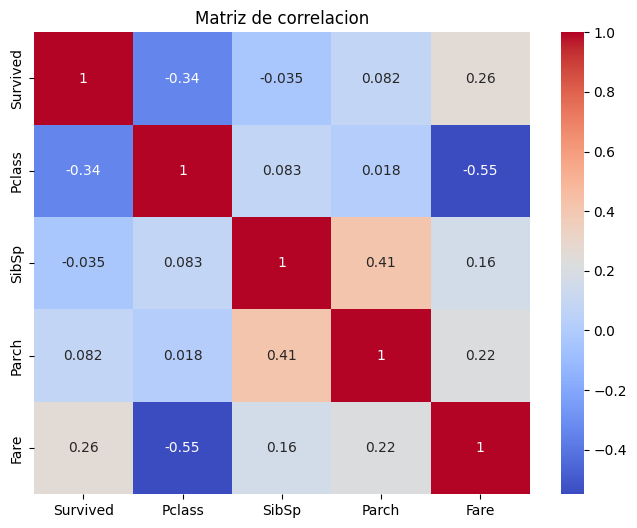

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlacion")
plt.show()

## Parte 4. Variables predictorias.

X --> Aquellas variables que nos ayudan a predecir 
Y --> Variable objetivo

In [20]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [24]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
]

In [25]:
X = dfTitanic[columnas]
Y = dfTitanic["Survived"]

In [28]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [29]:
Y.name

'Survived'

In [30]:
## Parte 5. Limepieza de los datos

Realizaremos la imputacion de los datos, donde existan valores nulos.

In [31]:
#Revisamos si exiten valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [33]:
## Vamos a imputar los datos para el campo Edad

X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

C:\Users\eduar\AppData\Local\Temp\ipykernel_13164\3151056718.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [34]:
## Vamos imputar los datos para el campo Embarked, calculando la moda

X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\eduar\AppData\Local\Temp\ipykernel_13164\3912381371.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] = X["Embarked"].fillna(


In [35]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

In [ ]:
## Parte6. Normalizar los datos categorias  (Texto)
Los algoritmos de ML no entienden texto.

In [37]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [39]:
X= pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first=True
)       

In [40]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. Division de los datos

No debemos entrenar y evaluar utilizando los mismos datos.

In [41]:
X_train, X_test, Y_train, Y_test, = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

In [42]:
print("Entrenamiento: ", X_train.shape)

Entrenamiento:  (712, 6)


In [43]:
print("Prueba: ", X_test.shape)

Prueba:  (179, 6)


In [44]:
print("Entrenamiento Y: ", Y_train.shape)

Entrenamiento Y:  (712,)


In [45]:
print("Prueba Y: ", Y_test.shape)

Prueba Y:  (179,)
